# Árbol de decisión
LOs árboles de decisión son representaciones gráficas de posibles soluciones a una decisión basada en ciertas condiciones, es uno de los algoritmos de aprendizaje supervisados más utilizado en machine learning y pueden realizar tareas de clasificación o regresión. La comprensión de su funcionamiento es simple y a la ve muy potente.
* Aprendizaje supervisado
* Aprendizaje basado en modelos
* Son clasificadores nolineales 
* Permite la predicción de valores continuos y de valores discretos
* Determina si un valor pertenece a un nodo o a una clase3 distinta
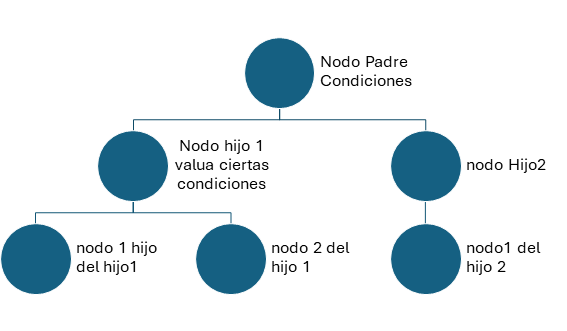
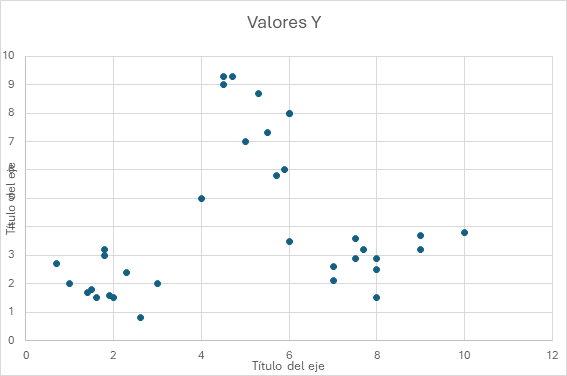
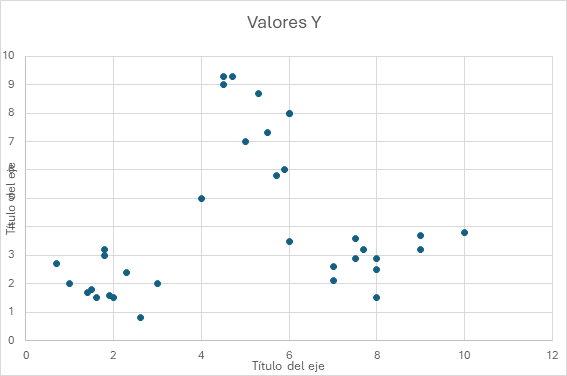

# Requerimientos para el ejercicio
Para realizar el ejercicio, utilizaremos un JupyterNotebook con código Python y la libreria Scikit learn muy utilizada en Data Science.
# Predicción de Billboard 100 ¿Qué artista llegará al número uno del ranking?
Apartir de atributos de cantantes y de un histórico de canciones que alcanzaron entrar al Billboard (USD) en 2013 y 2014 crearemis un árbol qeu nos permite intentar predecir si un nuevo cantante podrá llegar a número uno.
# Obtención de los datos
Se utilizo un código python para hacer webscraping de una web publica "Ultimate Music Database"

In [1]:
# Importamos las librerias
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize']=(16, 9)
plt.style.use('ggplot')
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont


# Cargamos los datos de entrada

In [2]:
artista=pd.read_csv(r"artists_billboard_fix3.csv")

In [3]:
artista.shape

(635, 11)

In [4]:
artista.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191.0,0,1975.0
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368.0,0,1989.0
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223.0,1,1993.0
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206.0,0,1989.0
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232.0,0,0.0


In [5]:
artista.groupby('top').size()

top
0    494
1    141
dtype: int64

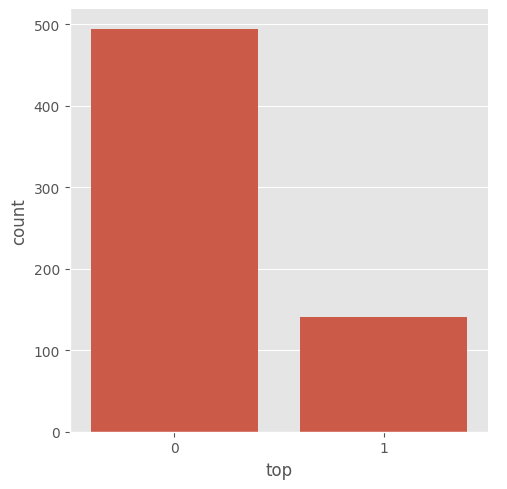

In [6]:
sb.catplot(x='top',data=artista,kind="count")
plt.show()

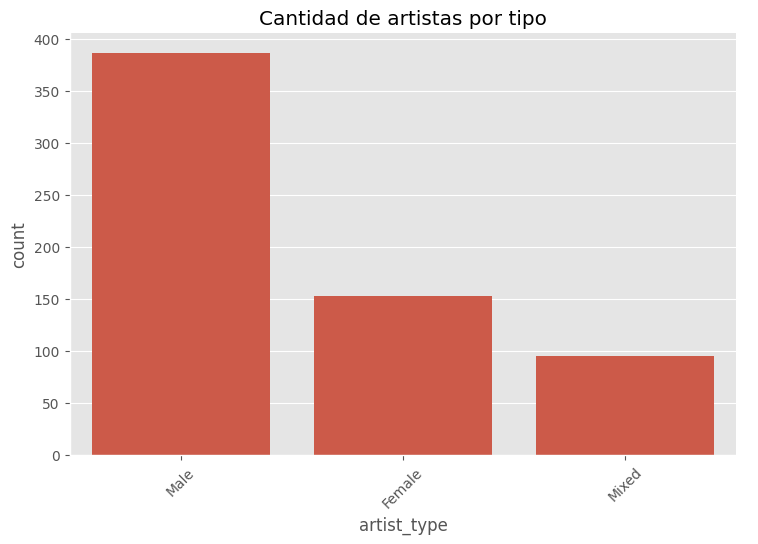

In [7]:
plot = sb.catplot(x='artist_type', data=artista, kind='count', height=5, aspect=1.5)
plot.set_xticklabels(rotation=45)
plt.title('Cantidad de artistas por tipo')
plt.show()

C:\Users\ADMIN-ITQ\AppData\Local\Temp\ipykernel_10372\2216475049.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.catplot(x='mood', data=artista, kind='count', aspect=3, palette='Set2')


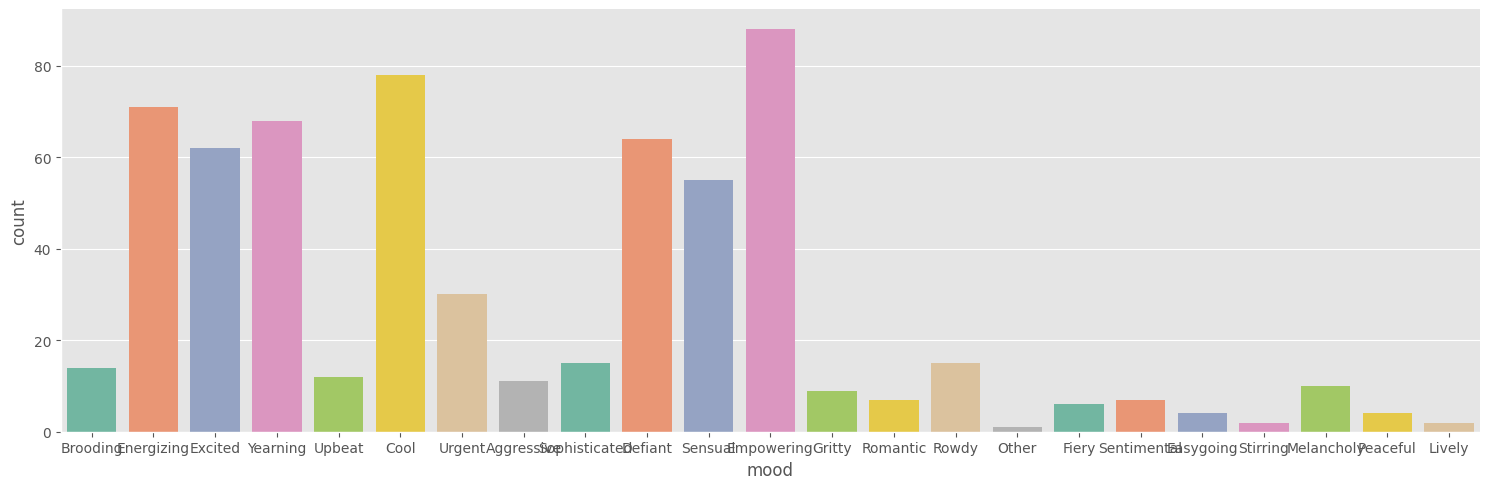

In [8]:
sb.catplot(x='mood', data=artista, kind='count', aspect=3, palette='Set2')
plt.show()

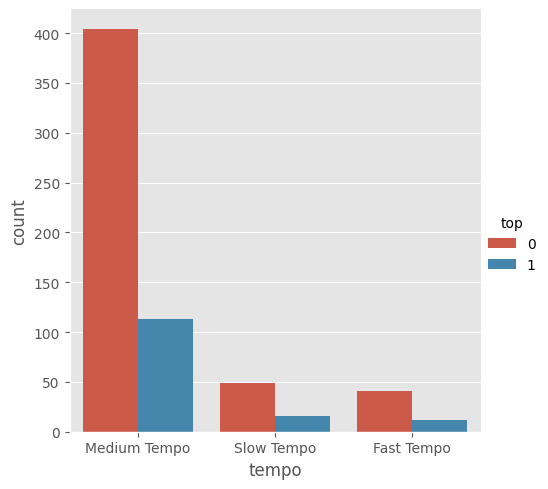

In [9]:
sb.catplot(x='tempo',data=artista,hue='top',kind="count")
plt.show()

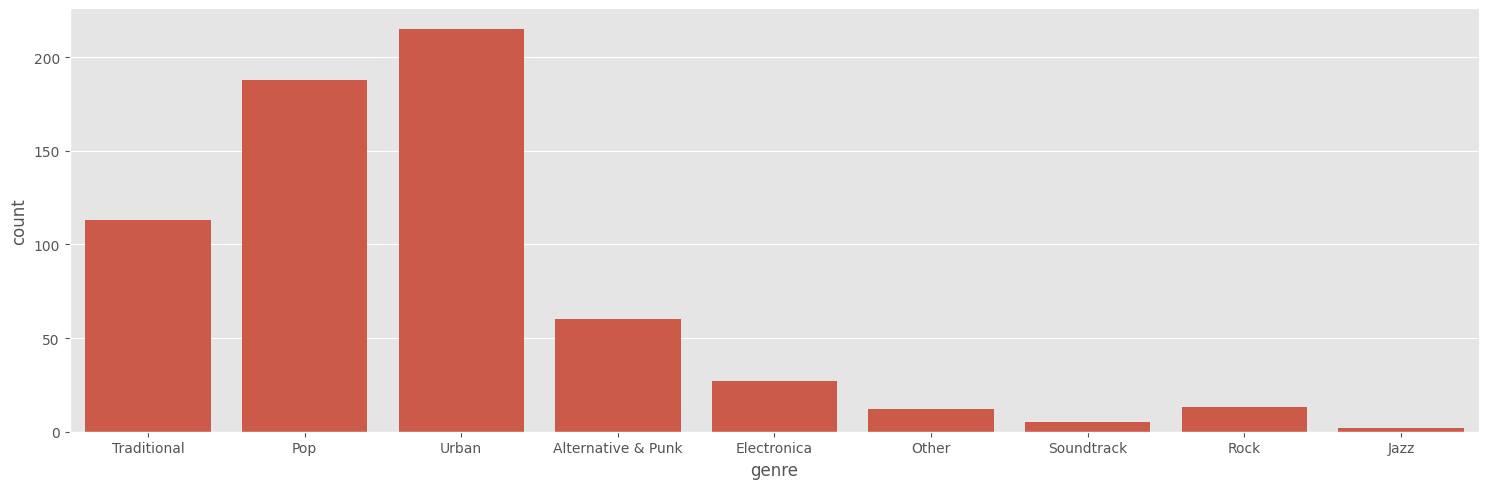

In [10]:
sb.catplot(x='genre',data=artista,kind="count", aspect=3)
plt.show()

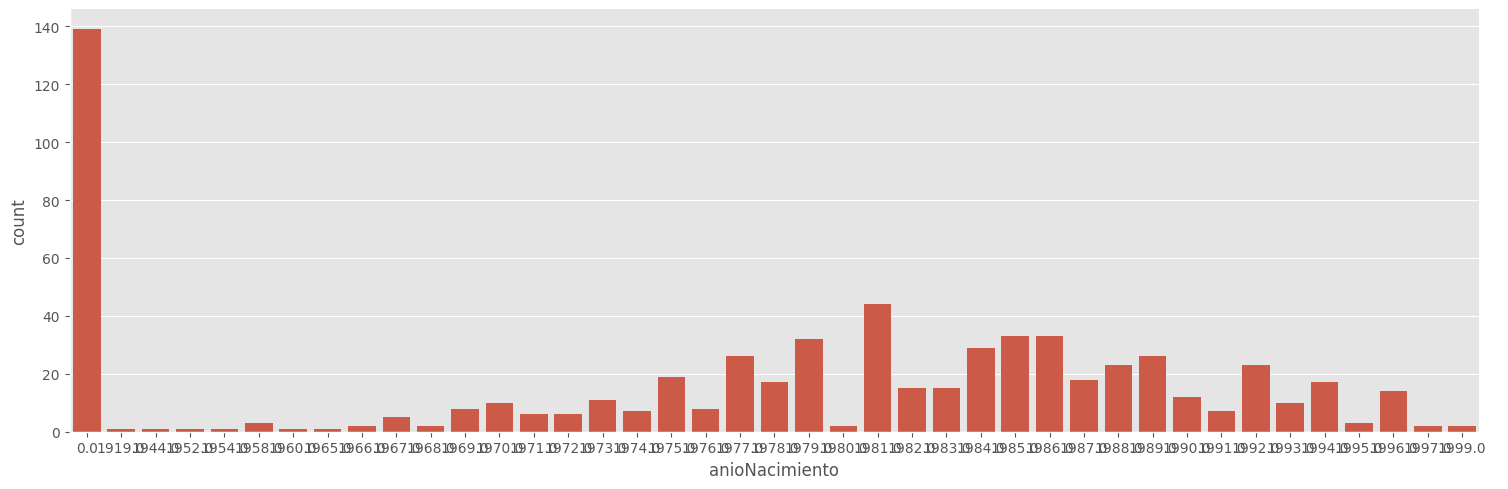

In [11]:
	
sb.catplot(x='anioNacimiento',data=artista,kind="count", aspect=3)
plt.show()

In [12]:

nacimientosPorAnio = artista['anioNacimiento']
len(nacimientosPorAnio[nacimientosPorAnio<=0])

139

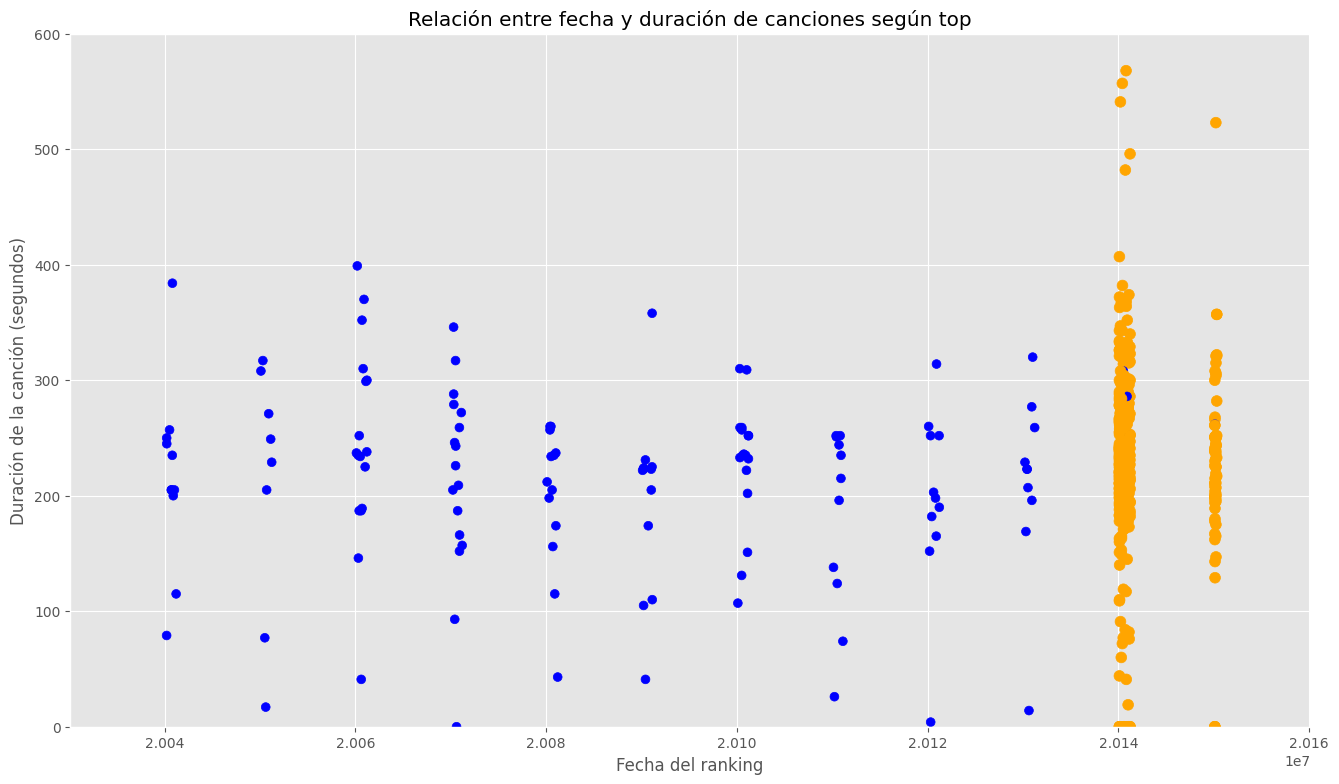

In [13]:
# Extrae las columnas necesarias del DataFrame
f1 = artista['chart_date'].values  # Fechas de aparición en el ranking (eje X)
f2 = artista['durationSeg'].values  # Duración de las canciones en segundos (eje Y)

# Definimos colores y tamaños para clasificar visualmente los puntos
colores = ['orange', 'blue']   # Color según si es top o no
tamanios = [60, 40]            # Tamaño del punto

# Listas para almacenar los valores calculados para cada punto
asignar = []    # Colores
asignar2 = []   # Tamaños

# Recorremos cada fila del DataFrame
for index, row in artista.iterrows():
    top_value = row['top']  # Obtenemos el valor de la columna 'top'
    
    # Asignamos color y tamaño según el valor
    if top_value == 1:
        asignar.append(colores[1])
        asignar2.append(tamanios[1])
    else:
        asignar.append(colores[0])
        asignar2.append(tamanios[0])

# Creamos el gráfico de dispersión
plt.scatter(f1, f2, c=asignar, s=asignar2)

# Configuramos los ejes
plt.axis([20030101, 20160101, 0, 600])  # Rango del eje X (fechas) y Y (segundos)

# Etiquetas del gráfico
plt.xlabel('Fecha del ranking')
plt.ylabel('Duración de la canción (segundos)')
plt.title('Relación entre fecha y duración de canciones según top')

# Mostramos el gráfico
plt.show()


Esto es porque inicialmente tomé información de 2014 y 2015 y había casi 500 no-top contra sólo 11 registros top. Entonces tomé a los artistas que alcanzaron el top entre 2004 y 2013 para sumar casos positivos y equilibrar un poco nuestros datos de entrada. Así y todo, sigue estando desbalanceado.

In [14]:
def edad_fix(anio):
    if anio==0:
        return None
    return anio

artista['anioNacimiento']=artista.apply(lambda x: edad_fix(x['anioNacimiento']), axis=1);

In [15]:
def calcula_edad(anio,cuando):
    cad = str(cuando)
    momento = cad[:4]
    if anio==0.0:
        return None
    return int(momento) - anio

artista['edad_en_billboard']=artista.apply(lambda x: calcula_edad(x['anioNacimiento'],x['chart_date']), axis=1);

In [16]:
artista.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento,edad_en_billboard
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191.0,0,1975.0,39.0
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368.0,0,1989.0,25.0
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223.0,1,1993.0,21.0
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206.0,0,1989.0,25.0
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232.0,0,NaN,NaN


# Calculamos promedio de edad y asignamos a los registros Nulos

In [17]:
#Calcula el promedio de los artistas que tienen un valor en la columna edad_en_billboard
age_avg = artista['edad_en_billboard'].mean()
#Calculca la desviación estándar de la edad, lo que indica qué tan dispersas están las edades con respecto alpromedio
age_std = artista['edad_en_billboard'].std()
# Contamos cuantos valore nulos hay en la columna de edad. Esto indica cuantos valores necesitmaos reeplazar.
age_null_count = artista['edad_en_billboard'].isnull().sum()
#Genera una lista de valores aleatorios enteros que simulan edades dentro del rango promedio +- desviación estandar, 
#para rellenar los valores nulos de de forma razonable
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
#CReamos una variabela boolenas para identificar que filas tiene valores nulos en la columna edad_billboard
conValoresNulos = np.isnan(artista['edad_en_billboard'])
#Reeplaza los valores nulos de la columna
#edad_en_billboard con los valores aleatorios generados anteriormente
artista.loc[np.isnan(artista['edad_en_billboard']), 'edad_en_billboard'] = age_null_random_list
#Convierte todos los valores de la columna de edad a números enteros, para mantener la
#coherencia (Por ejemplo, edad 27 en vez de 27.0)
artista['edad_en_billboard'] = artista['edad_en_billboard'].astype(int)

print("Edad Promedio: " + str(age_avg))
print("Desvió Std Edad: " + str(age_std))
print("Intervalo para asignar edad aleatoria: " + str(int(age_avg - age_std)) + " a " + str(int(age_avg + age_std)))

Edad Promedio: 30.10282258064516
Desvió Std Edad: 8.40078832861513
Intervalo para asignar edad aleatoria: 21 a 38


# Visualizamos las edades que agregamos

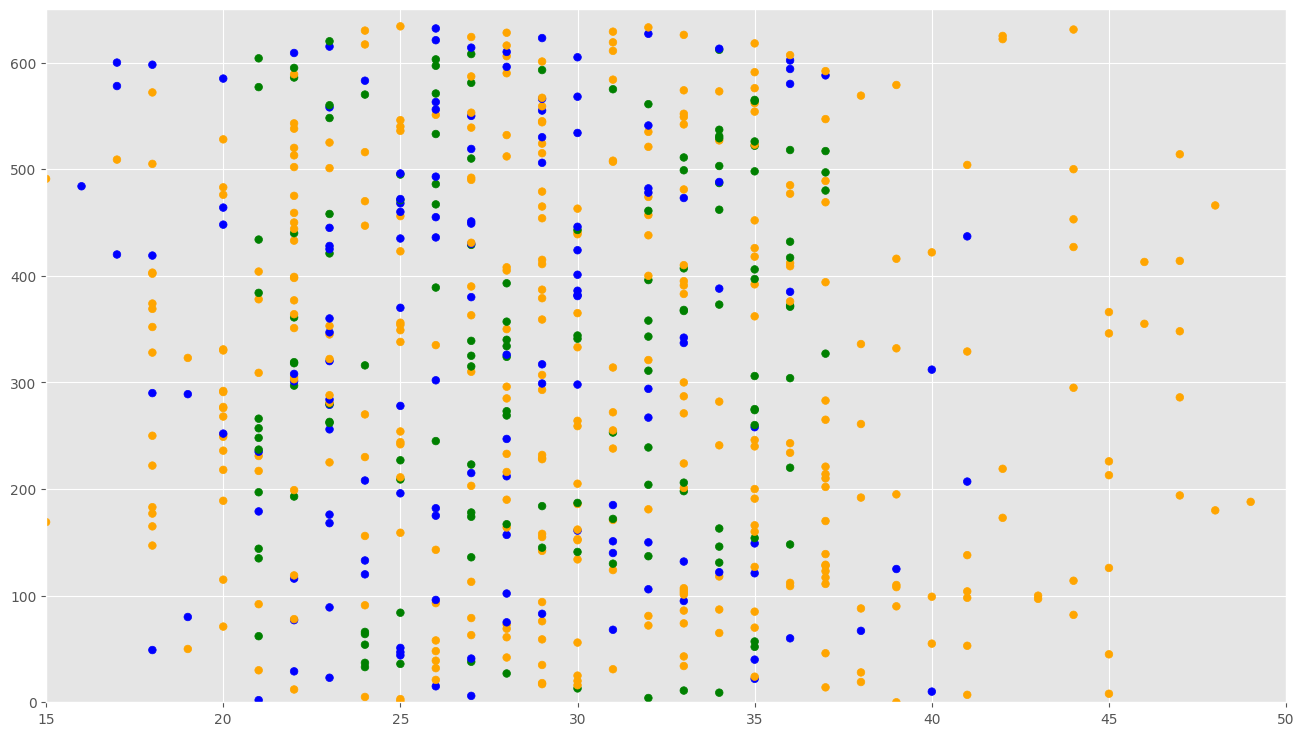

In [18]:
f1 = artista['edad_en_billboard'].values
f2 = artista.index

colores = ['orange','blue','green']

asignar=[]
for index, row in artista.iterrows():    
    if (conValoresNulos[index]):
        asignar.append(colores[2]) # verde
    else:
        asignar.append(colores[row['top']])

plt.scatter(f1, f2, c=asignar, s=30)
plt.axis([15,50,0,650])
plt.show()

In [19]:
+

mood
Empowering       88
Cool             78
Energizing       71
Yearning         68
Defiant          64
Excited          62
Sensual          55
Urgent           30
Rowdy            15
Sophisticated    15
Brooding         14
Upbeat           12
Aggressive       11
Melancholy       10
Gritty            9
Sentimental       7
Romantic          7
Fiery             6
Easygoing         4
Peaceful          4
Lively            2
Stirring          2
Other             1
dtype: int64
### ### ###
Tempos de Canción: ['Medium Tempo' 'Slow Tempo' 'Fast Tempo']
### ### ###
Tipos de Artista: ['Male' 'Female' 'Mixed']
### ### ###


In [20]:
# Mood Mapping 
artista['moodEncoded'] = artista['mood'].map( {'Energizing': 6, 
                                        'Empowering': 6,
                                        'Cool': 5, 
                                        'Yearning': 4, # anhelo, deseo, ansia
                                        'Excited': 5, #emocionado
                                        'Defiant': 3, 
                                        'Sensual': 2, 
                                        'Gritty': 3, #coraje 
                                        'Sophisticated': 4,
                                        'Aggressive': 4, # provocativo
                                        'Fiery': 4, #caracter fuerte
                                        'Urgent': 3, 
                                        'Rowdy': 4, #ruidoso alboroto
                                        'Sentimental': 4,
                                        'Easygoing': 1, # sencillo
                                        'Melancholy': 4, 
                                        'Romantic': 2, 
                                        'Peaceful': 1, 
                                        'Brooding': 4, # melancolico
                                        'Upbeat': 5, #optimista alegre
                                        'Stirring': 5, #emocionante
                                        'Lively': 5, #animado
                                        'Other': 0,'':0} ).astype(int)
# Tempo Mapping 
artista['tempoEncoded'] = artista['tempo'].map( {'Fast Tempo': 0, 'Medium Tempo': 2, 'Slow Tempo': 1, '': 0} ).astype(int)
# Genre Mapping 
artista['genreEncoded'] = artista['genre'].map( {'Urban': 4, 
                                          'Pop': 3, 
                                          'Traditional': 2, 
                                          'Alternative & Punk': 1,
                                         'Electronica': 1, 
                                          'Rock': 1, 
                                          'Soundtrack': 0, 
                                          'Jazz': 0,
                                          'Other':0,'':0} 
                                       ).astype(int)
# artist_type Mapping 
artista['artist_typeEncoded'] = artista['artist_type'].map( {'Female': 2, 'Male': 3, 'Mixed': 1, '': 0} ).astype(int)


# Mapping edad en la que llegaron al billboard
artista.loc[ artista['edad_en_billboard'] <= 21, 'edadEncoded'] 					       = 0
artista.loc[(artista['edad_en_billboard'] > 21) & (artista['edad_en_billboard'] <= 26), 'edadEncoded'] = 1
artista.loc[(artista['edad_en_billboard'] > 26) & (artista['edad_en_billboard'] <= 30), 'edadEncoded'] = 2
artista.loc[(artista['edad_en_billboard'] > 30) & (artista['edad_en_billboard'] <= 40), 'edadEncoded'] = 3
artista.loc[ artista['edad_en_billboard'] > 40, 'edadEncoded'] = 4

# Mapping Song Duration
artista.loc[ artista['durationSeg'] <= 150, 'durationEncoded'] 					       = 0
artista.loc[(artista['durationSeg'] > 150) & (artista['durationSeg'] <= 180), 'durationEncoded'] = 1
artista.loc[(artista['durationSeg'] > 180) & (artista['durationSeg'] <= 210), 'durationEncoded'] = 2
artista.loc[(artista['durationSeg'] > 210) & (artista['durationSeg'] <= 240), 'durationEncoded'] = 3
artista.loc[(artista['durationSeg'] > 240) & (artista['durationSeg'] <= 270), 'durationEncoded'] = 4
artista.loc[(artista['durationSeg'] > 270) & (artista['durationSeg'] <= 300), 'durationEncoded'] = 5
artista.loc[ artista['durationSeg'] > 300, 'durationEncoded'] = 6

In [21]:
drop_elements = ['id','title','artist','mood','tempo','genre','artist_type','chart_date','anioNacimiento','durationSeg','edad_en_billboard']
artists_encoded = artista.drop(drop_elements, axis = 1)

In [22]:

artists_encoded.head()

,top,moodEncoded,tempoEncoded,genreEncoded,artist_typeEncoded,edadEncoded,durationEncoded
0,0,4,2,2,3,3.0,2.0
1,0,6,2,3,2,1.0,6.0
2,1,5,2,4,1,0.0,3.0
3,0,4,2,1,3,1.0,2.0
4,0,4,2,2,2,3.0,3.0


In [23]:

artists_encoded.describe()

,top,moodEncoded,tempoEncoded,genreEncoded,artist_typeEncoded,edadEncoded,durationEncoded
count,635.000000,635.000000,635.000000,635.000000,635.000000,635.000000,635.000000
mean,0.222047,4.344882,1.730709,2.755906,2.459843,2.028346,3.179528
std,0.415950,1.350003,0.603553,1.165463,0.740583,1.154807,1.775017
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000
50%,0.000000,4.000000,2.000000,3.000000,3.000000,2.000000,3.000000
75%,0.000000,5.500000,2.000000,4.000000,3.000000,3.000000,4.000000
max,1.000000,6.000000,2.000000,4.000000,3.000000,4.000000,6.000000


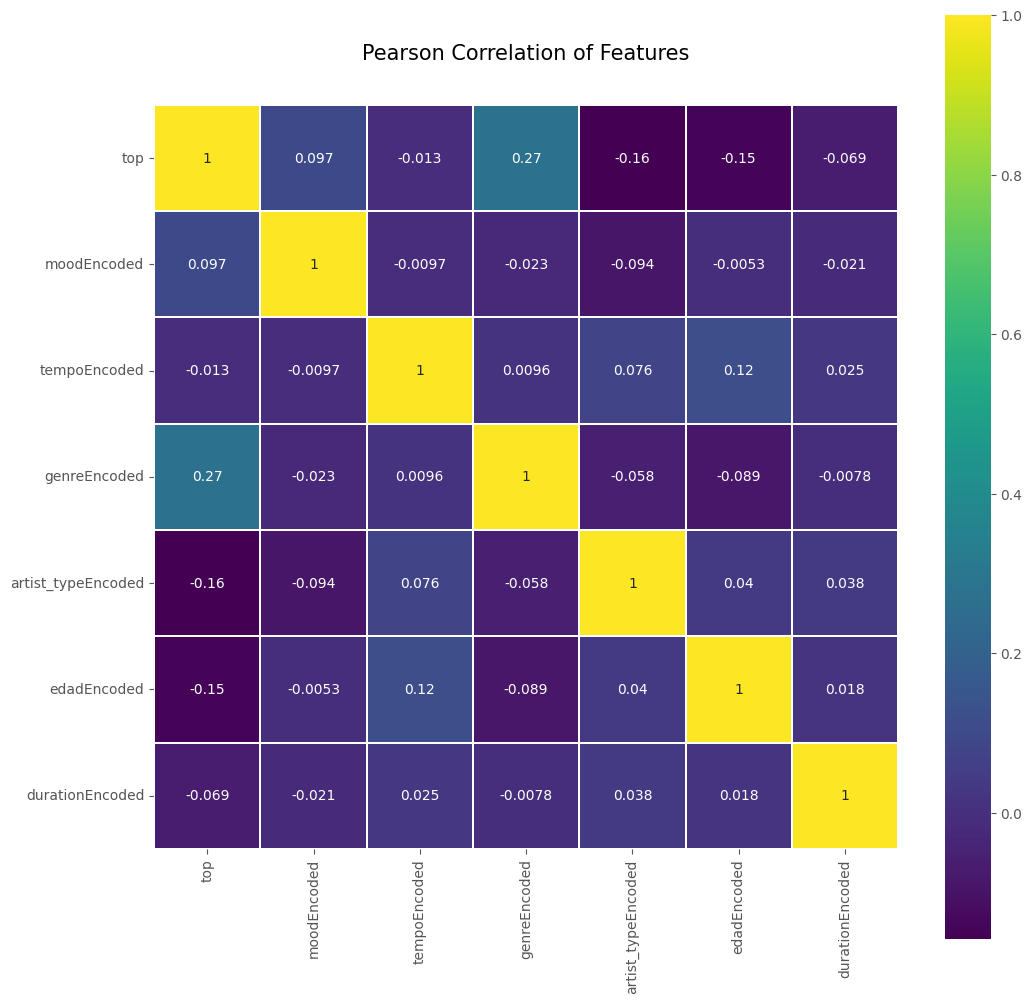

In [24]:
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sb.heatmap(artists_encoded.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)
plt.show()

In [25]:
artists_encoded[['moodEncoded', 'top']].groupby(['moodEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

moodEncoded       top          
                   mean count sum
0           0  0.000000     1   0
1           1  0.000000     8   0
2           2  0.274194    62  17
3           3  0.145631   103  15
4           4  0.136986   146  20
5           5  0.294872   156  46
6           6  0.270440   159  43

In [26]:
artists_encoded[['artist_typeEncoded', 'top']].groupby(['artist_typeEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

artist_typeEncoded       top          
                          mean count sum
0                  1  0.305263    95  29
1                  2  0.320261   153  49
2                  3  0.162791   387  63

In [27]:
artists_encoded[['genreEncoded', 'top']].groupby(['genreEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

genreEncoded       top          
                    mean count sum
0            0  0.105263    19   2
1            1  0.070000   100   7
2            2  0.008850   113   1
3            3  0.319149   188  60
4            4  0.330233   215  71

In [28]:
artists_encoded[['tempoEncoded', 'top']].groupby(['tempoEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

tempoEncoded       top           
                    mean count  sum
0            0  0.226415    53   12
1            1  0.246154    65   16
2            2  0.218569   517  113

In [29]:
artists_encoded[['durationEncoded', 'top']].groupby(['durationEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

durationEncoded       top          
                       mean count sum
0             0.0  0.295775    71  21
1             1.0  0.333333    30  10
2             2.0  0.212963   108  23
3             3.0  0.202381   168  34
4             4.0  0.232143   112  26
5             5.0  0.145455    55   8
6             6.0  0.208791    91  19

In [30]:
artists_encoded[['edadEncoded', 'top']].groupby(['edadEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

edadEncoded       top          
                   mean count sum
0         0.0  0.236111    72  17
1         1.0  0.317881   151  48
2         2.0  0.253425   146  37
3         3.0  0.168950   219  37
4         4.0  0.042553    47   2

In [31]:
cv = KFold(n_splits=10) # Numero deseado de "folds" que haremos
accuracies = list()
max_attributes = len(list(artists_encoded))
depth_range = range(1, max_attributes + 1)

In [32]:
# Testearemos la profundidad de 1 a cantidad de atributos +1
for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(criterion='entropy',
                                             min_samples_split=20,
                                             min_samples_leaf=5,
                                             max_depth = depth,
                                             class_weight={1:3.5})
    for train_fold, valid_fold in cv.split(artists_encoded):
        f_train = artists_encoded.loc[train_fold] 
        f_valid = artists_encoded.loc[valid_fold] 

        model = tree_model.fit(X = f_train.drop(['top'], axis=1), 
                               y = f_train["top"]) 
        valid_acc = model.score(X = f_valid.drop(['top'], axis=1), 
                                y = f_valid["top"]) # calculamos la precision con el segmento de validacion
        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy)/len(fold_accuracy)
    accuracies.append(avg)

In [33]:
# Mostramos los resultados obtenidos
df = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
df = df[["Max Depth", "Average Accuracy"]]
print(df.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.556101
         2          0.556126
         3          0.564038
         4          0.645660
         5          0.611062
         6          0.626811
         7          0.647222


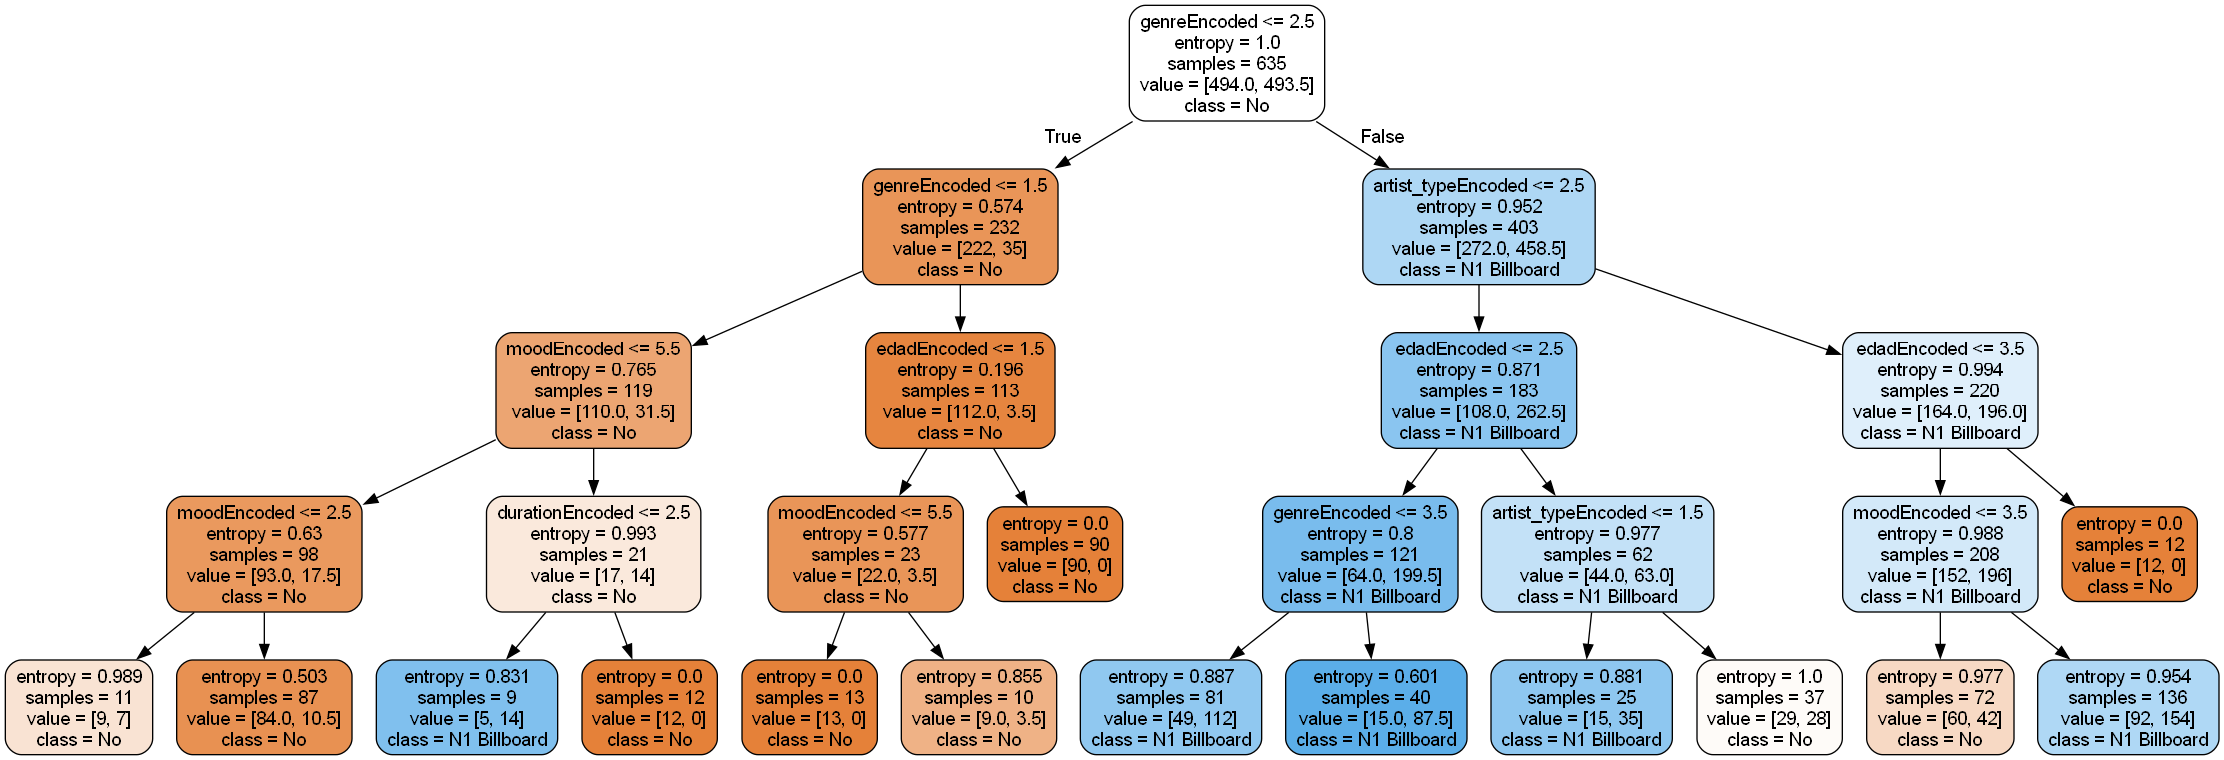

In [34]:
# Crear arrays de entrenamiento y las etiquetas que indican si llegó a top o no 
y_train = artists_encoded['top']
x_train = artists_encoded.drop(['top'], axis=1).values 

# Crear Arbol de decision con profundidad = 4
decision_tree = tree.DecisionTreeClassifier(criterion='entropy',
                                            min_samples_split=20,
                                            min_samples_leaf=5,
                                            max_depth = 4,
                                            class_weight={1:3.5})
decision_tree.fit(x_train, y_train)

# exportar el modelo a archivo .dot
with open(r"tree1.dot", 'w') as f:
     f = tree.export_graphviz(decision_tree,
                              out_file=f,
                              max_depth = 7,
                              impurity = True,
                              feature_names = list(artists_encoded.drop(['top'], axis=1)),
                              class_names = ['No', 'N1 Billboard'],
                              rounded = True,
                              filled= True )
        
# Convertir el archivo .dot a png para poder visualizarlo
check_call(['dot','-Tpng',r'tree1.dot','-o',r'tree1.png'])
PImage("tree1.png")

# Precisión alcanzada

In [37]:
acc_decision_tree=round(decision_tree.score(x_train,y_train)*100,2)
print(acc_decision_tree)

68.19


# Predicción

In [44]:
# predecir artista Camila Cabello 
# con su cancion havana. llego a numero 1 dede billboard en 2017
x_test=pd.DataFrame(columns=('top','moodEncoded','tempoEncoded','genreEncoded','artist_typeEncoded','edadEncoded','durationEncoded'))
x_test.loc[0]=(1,5,2,4,1,0,3)
y_pred=decision_tree.predict(x_test.drop(['top'], axis=1))
print("Prediccion: " +str(y_pred))
y_proba=decision_tree.predict_proba(x_test.drop(['top'], axis =1))
print(y_proba)

Prediccion: [1]
[[0.14634146 0.85365854]]


C:\Users\ADMIN-ITQ\anaconda3\envs\maquinas1\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\ADMIN-ITQ\anaconda3\envs\maquinas1\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Imagine Dragons
# Con su cancion Believer
# 0,4,2,1,3,2,3